# Eotvos correction

The Eotvos correction is a necessary correction to apply for any gravity surveys conducted on a moving platform, such as a ship or airplane. The correction accounts for the relative motion between the vehicle and the Earth's surface, which generates an additional centrifugal force known as the Eotvos effect. We offer several methods of computing the correction, which we show here, generally from simpliest to most complex.

In [ ]:
# %load_ext autoreload
# %autoreload 2

import pandas as pd
import plotly.io as pio
import verde as vd

import airbornegeo

pio.renderers.default = "notebook"

/home/sungw937/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is downloaded and subset in the notebook `AGAP_gravity_survey`. It has a pre-computed Eotvos correction, which we will compare our computed values to.

In [2]:
data_df = pd.read_csv("data/AGAP_gravity_survey.csv")
print(data_df.columns)
data_df.head()

Index(['Lon', 'Lat', 'Height_WGS1984', 'Date', 'Time', 'ST', 'CC', 'RB',
       'XACC', 'LACC', 'Still', 'Base', 'ST_real', 'Beam_vel', 'rec_grav',
       'Abs_grav', 'VaccCor', 'EotvosCor', 'LatCor', 'FaCor', 'HaccCor',
       'Free_air', 'FAA_filt', 'FAA_clip', 'Level_cor', 'FAA_level',
       'Fa_4600m', 'easting', 'northing', 'line_name', 'line', 'unixtime'],
      dtype='str')


,Lon,Lat,Height_WGS1984,Date,Time,ST,CC,RB,XACC,LACC,...,FAA_filt,FAA_clip,Level_cor,FAA_level,Fa_4600m,easting,northing,line_name,line,unixtime
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,49.38,49.38,7.03,42.4,40.8,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,49.45,49.45,7.04,42.4,40.8,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,49.52,49.52,7.04,42.5,40.9,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,49.58,49.58,7.03,42.5,40.9,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,49.65,49.65,7.04,42.6,41.0,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09


In [3]:
data_df["distance_along_line"] = airbornegeo.along_track_distance(
    data_df,
    groupby_column="line",
)

In [4]:
# get only the raw columns
# we will perform the corrections ourselves and compare to their values
data_df = data_df[
    [
        "EotvosCor",
        "Lon",
        "Lat",
        "Height_WGS1984",
        "easting",
        "northing",
        "unixtime",
        "line",
        "distance_along_line",
    ]
]
data_df.head()

,EotvosCor,Lon,Lat,Height_WGS1984,easting,northing,unixtime,line,distance_along_line
0,68.15,77.252450,-80.583923,4156.1,1.000024e+06,226237.330771,1.229507e+09,1,0.000000
1,68.37,77.252672,-80.583377,4156.0,1.000083e+06,226246.631269,1.229507e+09,1,59.842447
2,68.37,77.252901,-80.582831,4156.1,1.000142e+06,226255.809132,1.229507e+09,1,119.693401
3,68.16,77.253131,-80.582285,4156.4,1.000201e+06,226264.969079,1.229507e+09,1,179.545645
4,68.12,77.253358,-80.581740,4156.6,1.000260e+06,226274.156809,1.229507e+09,1,239.285174


## Eotvos correction following Glicken 1962

The most simple method of calculating the Eotvos correction is the [Glicken 1962](https://doi.org/10.1190/1.1439057) formula, which depends on only the latitudes, the track angle, and the ground speed.

The track angle is similar to the aircraft's heading. The heading is the angle the nose of the plane points, which due to wind, can differ from the angle the path of the plane makes. This is in degrees clockwise from geographic north.

By setting `ellipsoid=True` in the below funciton, we calculate the track using the WGS84 ellipsoid, instead of using a simplified spheric model of the Earth. It is more accurate, but a bit slower to compute.

In [5]:
data_df["track"] = airbornegeo.track(
    data_df,
    latitude_column="Lat",
    longitude_column="Lon",
    groupby_column="line",
    ellipsoid=False,  # this is faster
)
data_df.head()

Segments: 100%|██████████| 100/100 [00:00<00:00, 2074.24it/s]


,EotvosCor,Lon,Lat,Height_WGS1984,easting,northing,unixtime,line,distance_along_line,track
0,68.15,77.252450,-80.583923,4156.1,1.000024e+06,226237.330771,1.229507e+09,1,0.000000,NaN
1,68.37,77.252672,-80.583377,4156.0,1.000083e+06,226246.631269,1.229507e+09,1,59.842447,3.805916
2,68.37,77.252901,-80.582831,4156.1,1.000142e+06,226255.809132,1.229507e+09,1,119.693401,3.925778
3,68.16,77.253131,-80.582285,4156.4,1.000201e+06,226264.969079,1.229507e+09,1,179.545645,3.943093
4,68.12,77.253358,-80.581740,4156.6,1.000260e+06,226274.156809,1.229507e+09,1,239.285174,3.899163


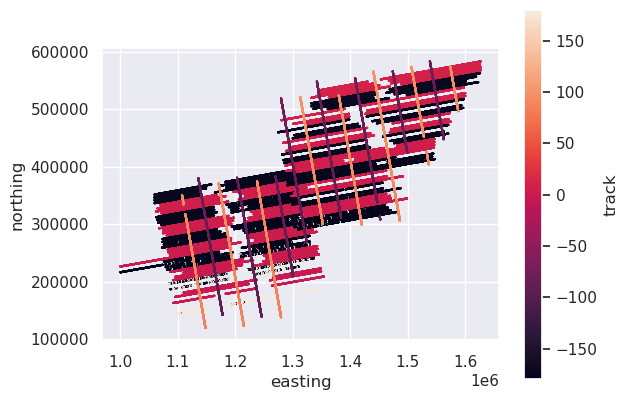

In [6]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="track",
    s=0.2,
)
ax.set_aspect("equal")

The other component needed for the Glicken formulation of the Eotvos correction calculation is the velocity of the aircraft. The below function `ground_speed` calculats the relative distance between successive rows in the dataframe. This assumes the dataframe is sorted by line, and then by time. From the relative distance, it then calculate the ground speed of the aircraft. 

In [7]:
data_df["ground_speed"] = airbornegeo.ground_speed(
    data_df,
    easting_column="easting",
    northing_column="northing",
    time_column="unixtime",
    groupby_column="line",
)
data_df.head()

Segments: 100%|██████████| 100/100 [00:00<00:00, 3544.88it/s]


,EotvosCor,Lon,Lat,Height_WGS1984,easting,northing,unixtime,line,distance_along_line,track,ground_speed
0,68.15,77.252450,-80.583923,4156.1,1.000024e+06,226237.330771,1.229507e+09,1,0.000000,NaN,59.842447
1,68.37,77.252672,-80.583377,4156.0,1.000083e+06,226246.631269,1.229507e+09,1,59.842447,3.805916,59.846701
2,68.37,77.252901,-80.582831,4156.1,1.000142e+06,226255.809132,1.229507e+09,1,119.693401,3.925778,59.851599
3,68.16,77.253131,-80.582285,4156.4,1.000201e+06,226264.969079,1.229507e+09,1,179.545645,3.943093,59.795886
4,68.12,77.253358,-80.581740,4156.6,1.000260e+06,226274.156809,1.229507e+09,1,239.285174,3.899163,59.740782


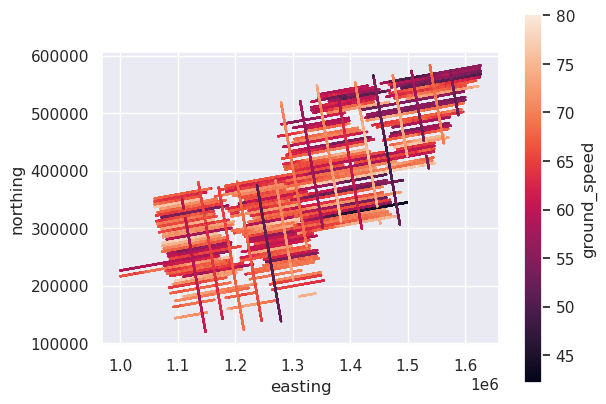

In [8]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="ground_speed",
    s=0.2,
)
ax.set_aspect("equal")

In [9]:
data_df["eotvos_correction_glicken"] = airbornegeo.eotvos_correction_glicken(
    data_df.Lat.values,
    data_df.track.values,
    data_df.ground_speed.values,
)
data_df.head()

,EotvosCor,Lon,Lat,Height_WGS1984,easting,northing,unixtime,line,distance_along_line,track,ground_speed,eotvos_correction_glicken
0,68.15,77.252450,-80.583923,4156.1,1.000024e+06,226237.330771,1.229507e+09,1,0.000000,NaN,59.842447,NaN
1,68.37,77.252672,-80.583377,4156.0,1.000083e+06,226246.631269,1.229507e+09,1,59.842447,3.805916,59.846701,65.696167
2,68.37,77.252901,-80.582831,4156.1,1.000142e+06,226255.809132,1.229507e+09,1,119.693401,3.925778,59.851599,66.004804
3,68.16,77.253131,-80.582285,4156.4,1.000201e+06,226264.969079,1.229507e+09,1,179.545645,3.943093,59.795886,65.934659
4,68.12,77.253358,-80.581740,4156.6,1.000260e+06,226274.156809,1.229507e+09,1,239.285174,3.899163,59.740782,65.713724


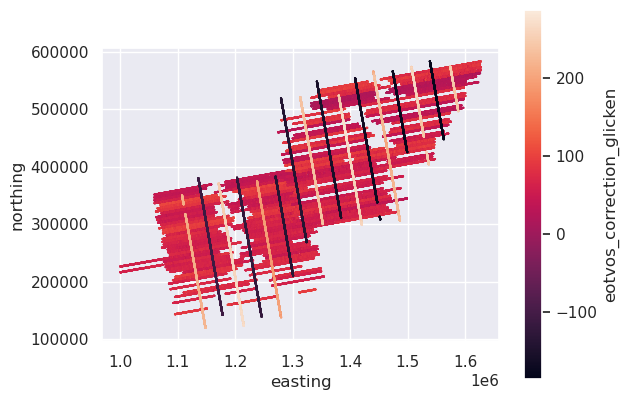

In [10]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="eotvos_correction_glicken",
    s=0.2,
)
ax.set_aspect("equal")

Text(0, 0.5, 'Eotvos correction (mGal)')

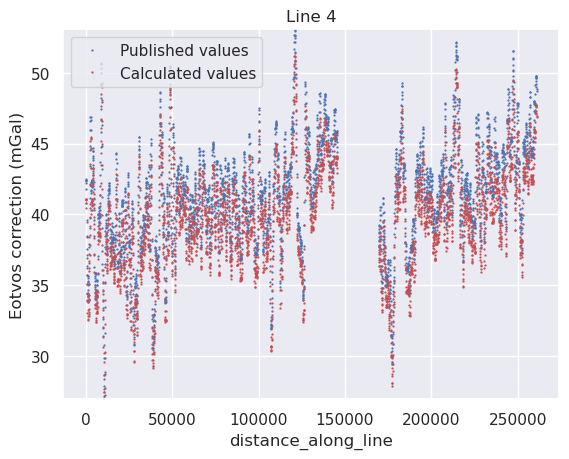

In [11]:
df = data_df[data_df.line == 4]
ylim = vd.minmax(df.EotvosCor)
ax = df.plot.line(
    "distance_along_line",
    "EotvosCor",
    style="bp",
    ms=0.6,
    label="Published values",
    title=f"Line {df.line.unique()[0]}",
    ylim=ylim,
)
ax = df.plot.line(
    "distance_along_line",
    "eotvos_correction_glicken",
    style="rp",
    ms=0.6,
    title=f"Line {df.line.unique()[0]}",
    label="Calculated values",
    ax=ax,
    ylim=ylim,
)
ax.set_ylabel("Eotvos correction (mGal)")

## Eotvos correction following Harlan 1968

Another common method to compute the correction is from [Harlan 1968](https://doi.org/10.1029/JB073i014p04675). The paper offers several equations, but first we will follow equation 15. 

### Equation 15: using aircraft track
This formulation requires the aircraft latitude, track, groundspeed, and height.

In [12]:
data_df["eotvos_correction_harlan_track"] = airbornegeo.eotvos_correction_harlan_track(
    data_df.Lat.values,
    data_df.track.values,
    data_df.ground_speed.values,
    data_df.Height_WGS1984.values,
)
data_df.head()

,EotvosCor,Lon,Lat,Height_WGS1984,easting,northing,unixtime,line,distance_along_line,track,ground_speed,eotvos_correction_glicken,eotvos_correction_harlan_track
0,68.15,77.252450,-80.583923,4156.1,1.000024e+06,226237.330771,1.229507e+09,1,0.000000,NaN,59.842447,NaN,NaN
1,68.37,77.252672,-80.583377,4156.0,1.000083e+06,226246.631269,1.229507e+09,1,59.842447,3.805916,59.846701,65.696167,65.539698
2,68.37,77.252901,-80.582831,4156.1,1.000142e+06,226255.809132,1.229507e+09,1,119.693401,3.925778,59.851599,66.004804,65.848496
3,68.16,77.253131,-80.582285,4156.4,1.000201e+06,226264.969079,1.229507e+09,1,179.545645,3.943093,59.795886,65.934659,65.778682
4,68.12,77.253358,-80.581740,4156.6,1.000260e+06,226274.156809,1.229507e+09,1,239.285174,3.899163,59.740782,65.713724,65.557979


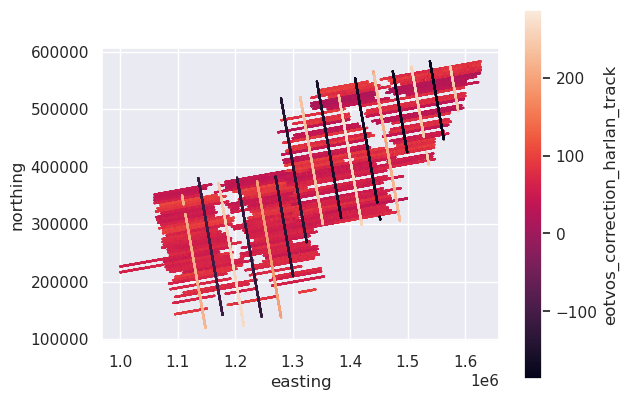

In [13]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="eotvos_correction_harlan_track",
    s=0.2,
)
ax.set_aspect("equal")

Text(0, 0.5, 'Eotvos correction (mGal)')

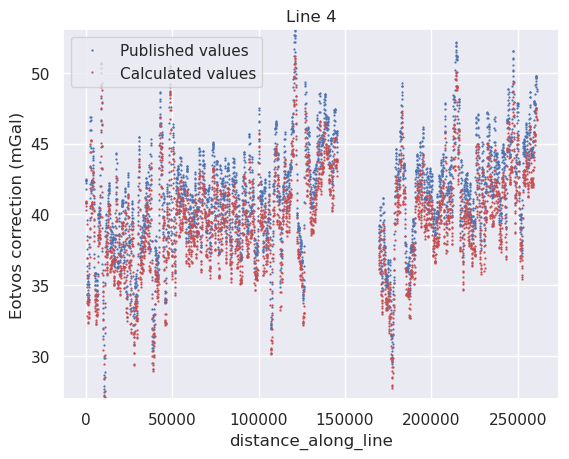

In [14]:
df = data_df[data_df.line == 4]
ylim = vd.minmax(df.EotvosCor)
ax = df.plot.line(
    "distance_along_line",
    "EotvosCor",
    style="bp",
    ms=0.6,
    label="Published values",
    title=f"Line {df.line.unique()[0]}",
    ylim=ylim,
)
ax = df.plot.line(
    "distance_along_line",
    "eotvos_correction_harlan_track",
    style="rp",
    ms=0.6,
    title=f"Line {df.line.unique()[0]}",
    label="Calculated values",
    ax=ax,
    ylim=ylim,
)
ax.set_ylabel("Eotvos correction (mGal)")

### Equation 15: using aircraft track
This formulation requires the aircraft latitude, latitudinal and longitudinal velocities, and height.

In [15]:
data_df["velocity_longitudinal"] = airbornegeo.directional_velocity(
    data_df,
    time_column="unixtime",
    coordinate_column="Lon",
    groupby_column="line",
)
data_df["velocity_latitudinal"] = airbornegeo.directional_velocity(
    data_df,
    time_column="unixtime",
    coordinate_column="Lat",
    groupby_column="line",
)

Segments: 100%|██████████| 100/100 [00:00<00:00, 2201.95it/s]


In [16]:
data_df["eotvos_correction_harlan_velocity"] = (
    airbornegeo.eotvos_correction_harlan_velocity(
        data_df.Lat.values,
        data_df.velocity_latitudinal.values,
        data_df.velocity_longitudinal.values,
        data_df.Height_WGS1984.values,
    )
)
data_df.head()

,EotvosCor,Lon,Lat,Height_WGS1984,easting,northing,unixtime,line,distance_along_line,track,ground_speed,eotvos_correction_glicken,eotvos_correction_harlan_track,velocity_longitudinal,velocity_latitudinal,eotvos_correction_harlan_velocity
0,68.15,77.252450,-80.583923,4156.1,1.000024e+06,226237.330771,1.229507e+09,1,0.000000,NaN,59.842447,NaN,NaN,0.000222,0.000546,68.079386
1,68.37,77.252672,-80.583377,4156.0,1.000083e+06,226246.631269,1.229507e+09,1,59.842447,3.805916,59.846701,65.696167,65.539698,0.000225,0.000546,68.241409
2,68.37,77.252901,-80.582831,4156.1,1.000142e+06,226255.809132,1.229507e+09,1,119.693401,3.925778,59.851599,66.004804,65.848496,0.000229,0.000546,68.426614
3,68.16,77.253131,-80.582285,4156.4,1.000201e+06,226264.969079,1.229507e+09,1,179.545645,3.943093,59.795886,65.934659,65.778682,0.000229,0.000546,68.275336
4,68.12,77.253358,-80.581740,4156.6,1.000260e+06,226274.156809,1.229507e+09,1,239.285174,3.899163,59.740782,65.713724,65.557979,0.000228,0.000545,68.147164


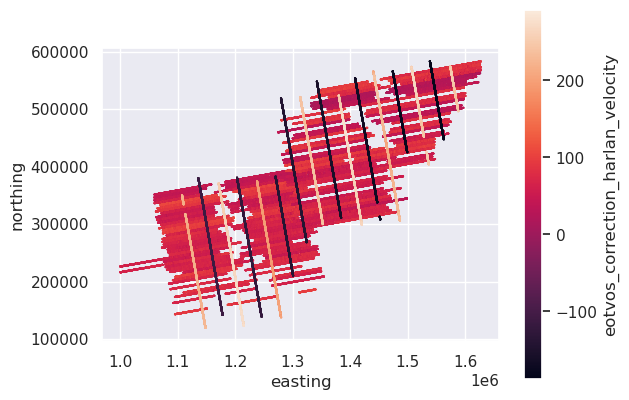

In [17]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="eotvos_correction_harlan_velocity",
    s=0.2,
)
ax.set_aspect("equal")

Text(0, 0.5, 'Eotvos correction (mGal)')

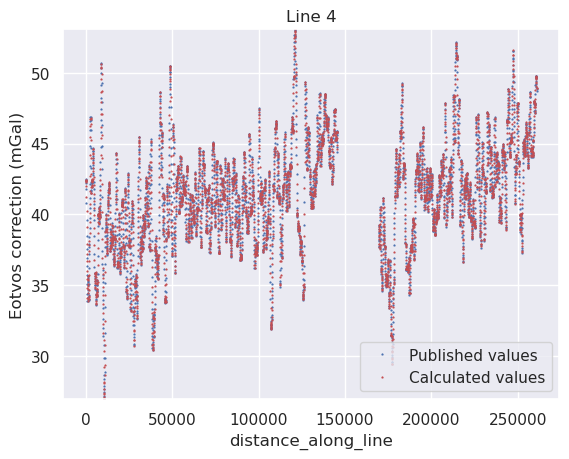

In [18]:
df = data_df[data_df.line == 4]
ylim = vd.minmax(df.EotvosCor)
ax = df.plot.line(
    "distance_along_line",
    "EotvosCor",
    style="bp",
    ms=0.6,
    label="Published values",
    title=f"Line {df.line.unique()[0]}",
    ylim=ylim,
)
ax = df.plot.line(
    "distance_along_line",
    "eotvos_correction_harlan_velocity",
    style="rp",
    ms=0.6,
    title=f"Line {df.line.unique()[0]}",
    label="Calculated values",
    ax=ax,
    ylim=ylim,
)
ax.set_ylabel("Eotvos correction (mGal)")

## Full Eotvos correction

The above methods used some assumptions to simplify the complex calculation for the Eotvos Correction. Below, we demonstrate the full analytic solution to the Eotvos correction equation. These methods utilize the 2nd temporal derivative of quantities such as latitude, longitude, and height, making them highly sensitive. If the data has been downsampled, the results will likely be skewed. 

In [110]:
# data_df["eotvos_correction_approx"] = airbornegeo.eotvos_correction_approx(
#     data_df.Lat.values,
#     data_df.Lon.values,
#     data_df.Height_WGS1984.values,
#     data_df.unixtime.values,
# )
# data_df["eotvos_correction_full"] = airbornegeo.eotvos_correction_full(
#     data_df.Lat.values,
#     data_df.Lon.values,
#     data_df.Height_WGS1984.values,
#     data_df.unixtime.values,
# )
# data_df.head()

In [109]:
# df = data_df[data_df.line == 4]
# df = df[df.distance_along_line < 140e3]

# ylim = vd.minmax(df[[
#         'eotvos_correction_approx',
#         'eotvos_correction_full',
#     ]],
#     min_percentile=.1, max_percentile=99.9)
# ax = df.plot.line(
#     "distance_along_line",
#     "eotvos_correction_approx",
#     style="rp",
#     ms=1.6,
#     ylim=ylim,
# )
# ax = df.plot.line(
#     "distance_along_line",
#     "eotvos_correction_full",
#     style="bp",
#     ms=0.4,
#     ax=ax,
#     ylim=ylim,
# )
# ax.set_ylabel("Eotvos correction (mGal)")

In [108]:
# df = data_df[data_df.line == 4]
# df = df[df.distance_along_line < 140e3]
# df = airbornegeo.resample(
#     df,
#     spacing=0.1,
#     resample_by="unixtime",
#     maxdist=10,
# )
# df.head()

In [107]:
# df.unixtime.iloc[0], df.unixtime.iloc[1]

In [ ]:
# # from https://www.boulama.com/blog/posts/smoothing-noisy-sensor-data-with-kalman-filters.html
# class KalmanFilter:
#     def __init__(self, process_variance, measurement_variance):
#         self.process_variance = process_variance
#         self.measurement_variance = measurement_variance
#         self.posteri_estimate = 0.0
#         self.posteri_error_estimate = 1.0

#     def update(self, measurement):
#         priori_estimate = self.posteri_estimate
#         priori_error_estimate = self.posteri_error_estimate + self.process_variance

#         blending_factor = priori_error_estimate / (priori_error_estimate + self.measurement_variance)
#         self.posteri_estimate = priori_estimate + blending_factor * (measurement - priori_estimate)
#         self.posteri_error_estimate = (1 - blending_factor) * priori_error_estimate

#         return self.posteri_estimate

In [105]:
# df["eotvos_correction_full"] = airbornegeo.eotvos_correction_full(
#     df.Lat.values,
#     df.Lon.values,
#     df.Height_WGS1984.values,
#     df.unixtime.values,
# )

# ylim = vd.minmax(
#     df['eotvos_correction_full'],
#     min_percentile=5,
#     max_percentile=95,
# )
# ax = df.plot.line(
#     "distance_along_line",
#     "EotvosCor",
#     style="rp",
#     ms=1.6,
#     ylim=ylim,
# )
# ax = df.plot.line(
#     "distance_along_line",
#     "eotvos_correction_full",
#     style="bp",
#     ms=0.4,
#     ax=ax,
#     ylim=ylim,
# )

# import scipy as sp
# # df['eotvos_correction_full'] = sp.signal.savgol_filter(
# #     x=df.eotvos_correction_full,
# #     window_length=1000,
# #     polyorder=2,
# # )
# # df['eotvos_correction_full'] = sp.signal.savgol_filter(
# #     x=df.eotvos_correction_full,
# #     window_length=1000,
# #     polyorder=2,
# # )
# # df['eotvos_correction_full'] = sp.signal.savgol_filter(
# #     x=df.eotvos_correction_full,
# #     window_length=1000,
# #     polyorder=2,
# # )

# # df['eotvos_correction_full'] = sp.signal.wiener(
# #     df.eotvos_correction_full,
# #     mysize=2001,
# # )
# # df['eotvos_correction_full'] = sp.signal.wiener(
# #     df.eotvos_correction_full,
# #     mysize=2001,
# # )
# # df['eotvos_correction_full'] = sp.signal.wiener(
# #     df.eotvos_correction_full,
# #     mysize=2001,
# # )
# # df['eotvos_correction_full'] = airbornegeo.filter_line(
# #     df,
# #     filter_type="g1000+l",
# #     data_column='eotvos_correction_full',
# #     filter_by_column="unixtime",
# #     # pad_mode="linear_ramp",
# #     pad_width_percentage=100,
# # )
# # df['eotvos_correction_full'] = airbornegeo.filter_line(
# #     df,
# #     filter_type="g1000+l",
# #     data_column='eotvos_correction_full',
# #     filter_by_column="unixtime",
# #     # pad_mode="linear_ramp",
# #     pad_width_percentage=100,
# # )


# kalman = KalmanFilter(
#     process_variance=0.0000001,
#     measurement_variance=10000,
# )

# # Apply Kalman filter
# df["eotvos_correction_full"] = [kalman.update(measurement) for measurement in df.eotvos_correction_full]


# ylim = vd.minmax(
#     df['eotvos_correction_full'],
#     min_percentile=5,
#     max_percentile=95,
# )
# ax = df.plot.line(
#     "distance_along_line",
#     "EotvosCor",
#     style="rp",
#     ms=1.6,
#     ylim=ylim,
# )
# ax = df.plot.line(
#     "distance_along_line",
#     "eotvos_correction_full",
#     style="bp",
#     ms=0.4,
#     ax=ax,
#     ylim=ylim,
# )
# df.head()